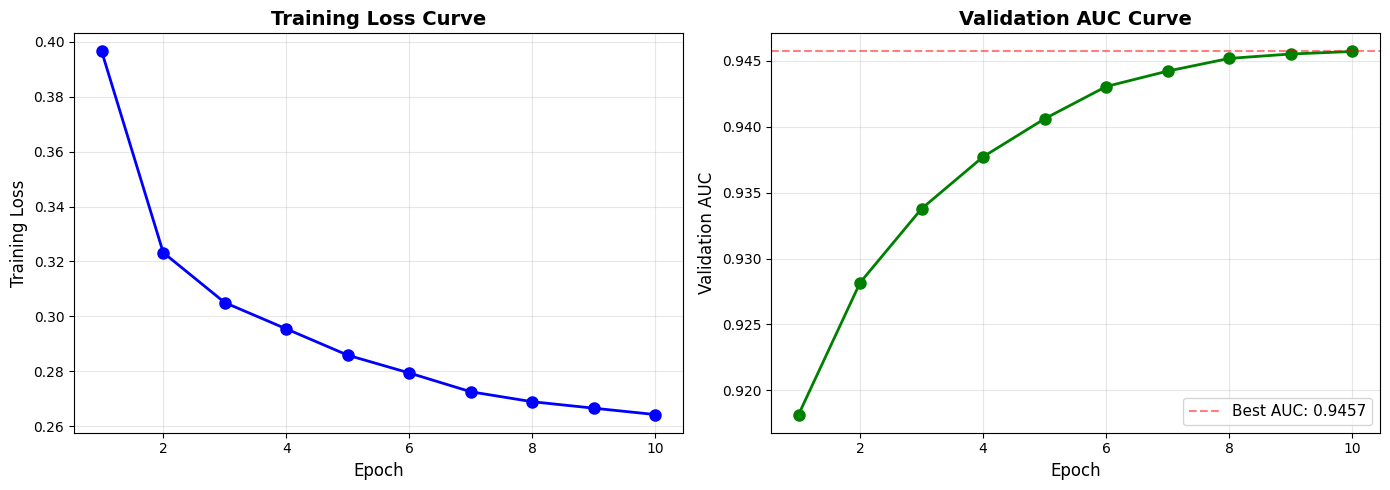

TRAINING SUMMARY
Total epochs: 10
Final train loss: 0.2643
Final val AUC: 0.9457
Best val AUC: 0.9457 (epoch 10)
Loss improvement: 0.3964 → 0.2643 (0.1321)
AUC improvement: 0.9182 → 0.9457 (+0.0275)

✅ No significant overfitting detected


In [2]:
# ========================================
# Visualize Training Results
# ========================================

import json
import matplotlib.pyplot as plt

# Load history
with open('../checkpoints/clip_medium_history.json', 'r') as f:
    history = json.load(f)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = history['epochs']
train_loss = history['train_loss']
val_auc = history['val_auc']

# Loss curve
ax1.plot(epochs, train_loss, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# AUC curve
ax2.plot(epochs, val_auc, 'g-o', linewidth=2, markersize=8)
ax2.axhline(y=max(val_auc), color='r', linestyle='--', alpha=0.5, 
            label=f'Best AUC: {max(val_auc):.4f}')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation AUC', fontsize=12)
ax2.set_title('Validation AUC Curve', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total epochs: {len(epochs)}")
print(f"Final train loss: {train_loss[-1]:.4f}")
print(f"Final val AUC: {val_auc[-1]:.4f}")
print(f"Best val AUC: {max(val_auc):.4f} (epoch {val_auc.index(max(val_auc)) + 1})")
print(f"Loss improvement: {train_loss[0]:.4f} → {train_loss[-1]:.4f} ({train_loss[0] - train_loss[-1]:.4f})")
print(f"AUC improvement: {val_auc[0]:.4f} → {max(val_auc):.4f} (+{max(val_auc) - val_auc[0]:.4f})")

# Check overfitting
if val_auc[-1] < max(val_auc) - 0.02:
    print("\n⚠️  Possible overfitting detected (val AUC decreasing)")
else:
    print("\n✅ No significant overfitting detected")